#  SiCASA — CataractScan: Pipeline Deteksi Katarak dengan YOLOv8

**Proyek:** Sistem Deteksi Dini Katarak (SiCASA)  
**Model:** YOLOv8 Object Detection  
**Dataset:** ODIR Cataract (Roboflow)  
**Kelas:** 2 — `Cataract` (0), `Normal` (1)  
**Author:** Brian  
**Environment:** `sicasa_gpu` (Anaconda + CUDA)  

---

###  Pipeline End-to-End:

| Tahap | Deskripsi |
|:-----:|:---------|
| 1 | Install & Import Library |
| 2 | Download Dataset dari Roboflow |
| 3 | Exploratory Data Analysis (EDA) |
| 4 | Data Cleaning & Validasi |
| 5 | Stratified Split (70/20/10) |
| 6 | Restrukturisasi Folder YOLOv8 |
| 7 | Generate `data.yaml` |
| 8 | Training Model YOLOv8 |
| 9 | Evaluasi & Analisis Performa |
| 10 | Visualisasi Hasil Prediksi |
| 11 | Deploy ke Web App SiCASA |

---

> **Catatan Riset:**  
> Seluruh pipeline ini dirancang agar **reproducible** (`seed=42`).  
> Stratified split memastikan distribusi kelas proporsional di setiap partisi.  
> Early stopping (`patience=20`) digunakan untuk mencegah overfitting.

---
## Tahap 1: Install & Import Library

In [1]:
# 
# 
# Jalankan cell ini SEKALI saja jika belum install

%pip install ultralytics roboflow scikit-learn \
             matplotlib seaborn pandas numpy \
             pillow opencv-python pyyaml tqdm --quiet

Note: you may need to restart the kernel to use updated packages.


In [1]:
# 
# 

import os
import sys
import shutil
import random
import yaml
import warnings
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from PIL import Image
from sklearn.model_selection import train_test_split
from tqdm.notebook import tqdm

import torch
from ultralytics import YOLO

# Konfigurasi plot
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
sns.set_palette('husl')
warnings.filterwarnings('ignore')

# Seed global — PENTING untuk reproduktibilitas
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

print("=" * 60)
print(" SiCASA — CataractScan Training Pipeline")
print("=" * 60)
print(f"Python         : {sys.version.split()[0]}")
print(f"PyTorch        : {torch.__version__}")
print(f"CUDA available : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU            : {torch.cuda.get_device_name(0)}")
    vram = torch.cuda.get_device_properties(0).total_memory / (1024**3)
    print(f"VRAM           : {vram:.1f} GB")
print(f"Random Seed    : {RANDOM_SEED}")
print("=" * 60)
print(" Semua library berhasil di-import!")

🏥 SiCASA — CataractScan Training Pipeline
Python         : 3.11.15
PyTorch        : 2.7.1+cu118
CUDA available : True
GPU            : NVIDIA GeForce RTX 3050 6GB Laptop GPU
VRAM           : 6.0 GB
Random Seed    : 42
✅ Semua library berhasil di-import!


In [2]:
# 
# 

PROJECT_ROOT      = Path.cwd()
RAW_DATASET_DIR   = PROJECT_ROOT / "Cataract-1"       # Dataset mentah dari Roboflow
CLEAN_DATASET_DIR = PROJECT_ROOT / "dataset"           # Dataset bersih hasil split
QUARANTINE_DIR    = PROJECT_ROOT / "_quarantine"       # File anomali
RUNS_DIR          = PROJECT_ROOT / "runs"              # Output training
APP_DIR           = PROJECT_ROOT / "app"               # Folder web app

# Konfigurasi kelas
CLASS_NAMES = {0: "Cataract", 1: "Normal"}
NUM_CLASSES = len(CLASS_NAMES)
CLASS_COLORS = {0: '#e74c3c', 1: '#2ecc71'}  # Merah untuk Cataract, Hijau untuk Normal

# Ekstensi gambar yang didukung
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp", ".tiff"}

print(f" Project root      : {PROJECT_ROOT}")
print(f" Raw dataset       : {RAW_DATASET_DIR}")
print(f" Clean dataset     : {CLEAN_DATASET_DIR}")
print(f" Quarantine        : {QUARANTINE_DIR}")
print(f" Runs              : {RUNS_DIR}")
print(f" App               : {APP_DIR}")
print(f"  Kelas ({NUM_CLASSES}): {CLASS_NAMES}")

📁 Project root      : d:\UDINUS\SEMESTER 4\PEMBELAJARAN MESIN\SiCASA
📁 Raw dataset       : d:\UDINUS\SEMESTER 4\PEMBELAJARAN MESIN\SiCASA\Cataract-1
📁 Clean dataset     : d:\UDINUS\SEMESTER 4\PEMBELAJARAN MESIN\SiCASA\dataset
📁 Quarantine        : d:\UDINUS\SEMESTER 4\PEMBELAJARAN MESIN\SiCASA\_quarantine
📁 Runs              : d:\UDINUS\SEMESTER 4\PEMBELAJARAN MESIN\SiCASA\runs
📁 App               : d:\UDINUS\SEMESTER 4\PEMBELAJARAN MESIN\SiCASA\app
🏷️  Kelas (2): {0: 'Cataract', 1: 'Normal'}


---
## Tahap 2: Download Dataset dari Roboflow

Dataset katarak dari Roboflow Universe. Jika folder `Cataract-1` sudah ada,  
cell ini akan **di-skip** agar tidak download ulang.

In [3]:
# 
# 

if RAW_DATASET_DIR.exists() and any(RAW_DATASET_DIR.iterdir()):
    print(f" Dataset sudah ada di: {RAW_DATASET_DIR}")
    print(f"   Skip download. Hapus folder '{RAW_DATASET_DIR.name}' jika ingin download ulang.")
else:
    print(" Mendownload dataset dari Roboflow...")
    from roboflow import Roboflow
    
    rf = Roboflow(api_key="ixfxZHKUIhnLLvNHMIEb")
    project = rf.workspace("brian-rqnbs").project("cataract-lt8ek-zefeq")
    version = project.version(1)
    dataset = version.download("yolov8", location=str(RAW_DATASET_DIR))
    
    print(f" Dataset berhasil didownload ke: {RAW_DATASET_DIR}")

✅ Dataset sudah ada di: d:\UDINUS\SEMESTER 4\PEMBELAJARAN MESIN\SiCASA\Cataract-1
   Skip download. Hapus folder 'Cataract-1' jika ingin download ulang.


In [4]:
# Cek struktur dataset yang didownload
print(" Struktur Dataset Mentah:")
print("-" * 50)
for split_name in ['train', 'valid', 'test']:
    img_dir = RAW_DATASET_DIR / split_name / 'images'
    lbl_dir = RAW_DATASET_DIR / split_name / 'labels'
    
    n_img = len(list(img_dir.glob('*'))) if img_dir.exists() else 0
    n_lbl = len(list(lbl_dir.glob('*.txt'))) if lbl_dir.exists() else 0
    
    print(f"   {split_name:<6} | images: {n_img:>5} | labels: {n_lbl:>5}")
print("-" * 50)

📂 Struktur Dataset Mentah:
--------------------------------------------------
   train  | images:  3114 | labels:  3114
   valid  | images:    20 | labels:    20
   test   | images:    10 | labels:    10
--------------------------------------------------


---
## Tahap 3: Exploratory Data Analysis (EDA)

Analisis mendalam terhadap dataset sebelum training:  
- Distribusi kelas  
- Distribusi dimensi gambar  
- Distribusi ukuran bounding box  
- Sampel gambar dengan anotasi bbox  

In [5]:
# 
# 

def collect_metadata(raw_dir: Path) -> pd.DataFrame:
    """
    Kumpulkan metadata dari seluruh dataset:
    nama file, sumber split, class_id, dimensi gambar, ukuran bbox.
    """
    records = []
    
    for split_name in ['train', 'valid', 'test']:
        img_dir = raw_dir / split_name / 'images'
        lbl_dir = raw_dir / split_name / 'labels'
        
        if not img_dir.exists():
            continue
        
        for img_file in sorted(img_dir.iterdir()):
            if img_file.suffix.lower() not in IMAGE_EXTENSIONS:
                continue
            
            lbl_file = lbl_dir / (img_file.stem + '.txt')
            
            # Baca dimensi gambar
            try:
                with Image.open(img_file) as img:
                    w, h = img.size
            except Exception:
                w, h = 0, 0
            
            # Baca label
            if lbl_file.exists():
                try:
                    text = lbl_file.read_text(encoding='utf-8').strip()
                    if text:
                        for line in text.splitlines():
                            parts = line.strip().split()
                            if len(parts) >= 5:
                                cls_id = int(parts[0])
                                bx, by, bw, bh = map(float, parts[1:5])
                                records.append({
                                    'filename': img_file.name,
                                    'source': split_name,
                                    'img_width': w,
                                    'img_height': h,
                                    'class_id': cls_id,
                                    'class_name': CLASS_NAMES.get(cls_id, f'Unknown_{cls_id}'),
                                    'bbox_x': bx,
                                    'bbox_y': by,
                                    'bbox_w': bw,
                                    'bbox_h': bh,
                                    'bbox_area': bw * bh,
                                })
                except Exception:
                    pass
    
    return pd.DataFrame(records)


print(" Mengumpulkan metadata dataset...")
df_meta = collect_metadata(RAW_DATASET_DIR)
print(f" {len(df_meta)} anotasi dari {df_meta['filename'].nunique()} gambar unik")
print(f"\n{df_meta.head(10)}")

🔍 Mengumpulkan metadata dataset...
✅ 3186 anotasi dari 3144 gambar unik

                                         filename source  img_width  \
0  10_JPG.rf.149025a854959ce3aeecf11d65defe96.jpg  train        640   
1  10_JPG.rf.2405d8c445bd23cd7cbcca2b6b8c4ebb.jpg  train        640   
2  10_JPG.rf.446d64c347d3af34e9c0e742a0f1261d.jpg  train        640   
3  10_JPG.rf.535f26993253ba7640058fafa1e47c5c.jpg  train        640   
4  10_JPG.rf.54938761c1df0949c40eb1819a1c0bf8.jpg  train        640   
5  10_JPG.rf.55008ddabba1c85b5415c636f153f5c5.jpg  train        640   
6  10_JPG.rf.5731a57d980ae5660f6072c0e27b641e.jpg  train        640   
7  10_JPG.rf.67e1ebb8590de768c9fa3333a0b13f27.jpg  train        640   
8  10_JPG.rf.845a6f3c8b78cdba775d55cd1fa5de3e.jpg  train        640   
9  10_JPG.rf.bd5947ce472968434420a95fa580d446.jpg  train        640   

   img_height  class_id class_name    bbox_x    bbox_y    bbox_w    bbox_h  \
0         640         0   Cataract  0.395313  0.502344  0.478125  0

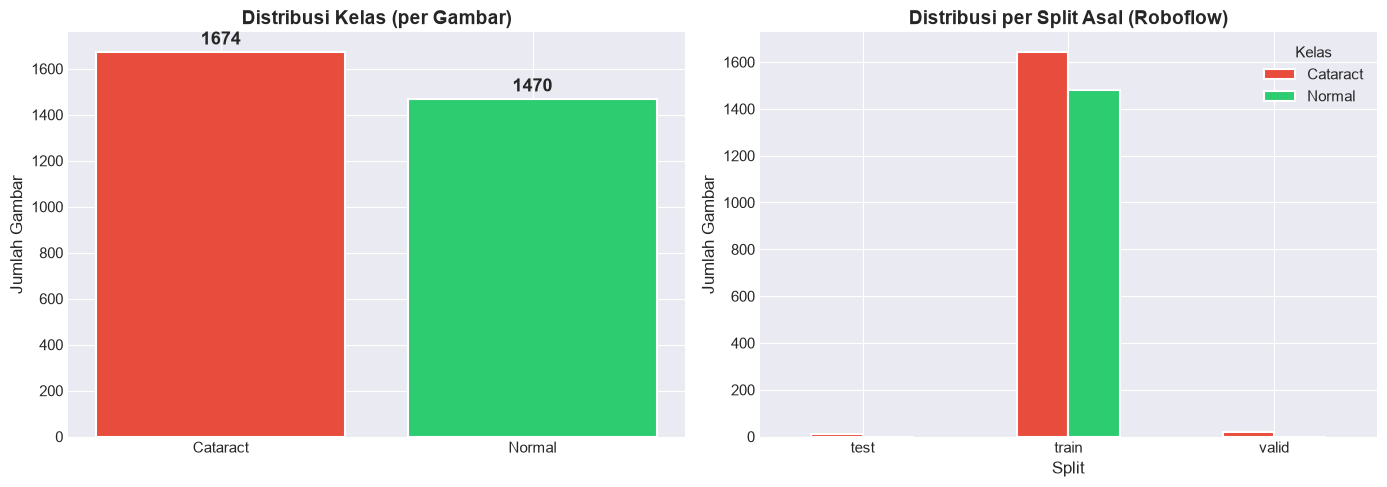


📊 Statistik Dataset:
   Total gambar unik : 3144
   Cataract         : 1674 (53.2%)
   Normal           : 1470 (46.8%)

   Imbalance ratio   : 1.14x
   ✅ Dataset cukup seimbang (< 1.5x)


In [7]:
# 
# 

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Per gambar unik (berdasarkan class_id pertama per gambar)
df_per_image = df_meta.groupby('filename')['class_id'].first().reset_index()
class_counts = df_per_image['class_id'].value_counts().sort_index()

colors = [CLASS_COLORS[i] for i in class_counts.index]
bars = axes[0].bar(
    [CLASS_NAMES[i] for i in class_counts.index],
    class_counts.values,
    color=colors,
    edgecolor='white',
    linewidth=1.5
)
for bar, count in zip(bars, class_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
                f'{count}', ha='center', va='bottom', fontweight='bold', fontsize=13)
axes[0].set_title('Distribusi Kelas (per Gambar)', fontweight='bold')
axes[0].set_ylabel('Jumlah Gambar')

# Per split asal
split_class = df_meta.groupby(['source', 'class_name'])['filename'].nunique().unstack(fill_value=0)
split_class.plot(kind='bar', ax=axes[1], color=[CLASS_COLORS[0], CLASS_COLORS[1]],
                 edgecolor='white', linewidth=1.5)
axes[1].set_title('Distribusi per Split Asal (Roboflow)', fontweight='bold')
axes[1].set_ylabel('Jumlah Gambar')
axes[1].set_xlabel('Split')
axes[1].legend(title='Kelas')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Statistik teks
total_imgs = df_meta['filename'].nunique()
print(f"\n Statistik Dataset:")
print(f"   Total gambar unik : {total_imgs}")
for cls_id in sorted(CLASS_NAMES.keys()):
    n = class_counts.get(cls_id, 0)
    pct = n / total_imgs * 100
    print(f"   {CLASS_NAMES[cls_id]:<10}       : {n} ({pct:.1f}%)")

# Cek imbalance ratio
imbalance = max(class_counts.values) / min(class_counts.values)
print(f"\n   Imbalance ratio   : {imbalance:.2f}x")
if imbalance < 1.5:
    print("    Dataset cukup seimbang (< 1.5x)")
else:
    print("     Dataset sedikit tidak seimbang — pertimbangkan augmentasi pada kelas minoritas")

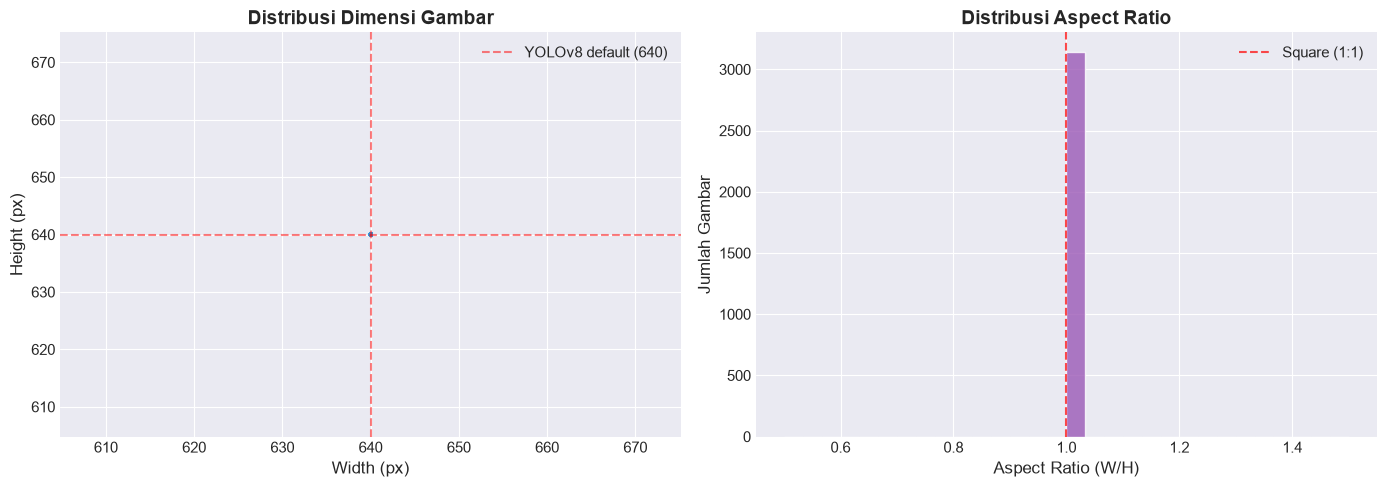

📏 Dimensi Gambar:
   Width  — min: 640, max: 640, mean: 640
   Height — min: 640, max: 640, mean: 640


In [8]:
# 
# 

df_dims = df_meta.groupby('filename')[['img_width', 'img_height']].first().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot dimensi
axes[0].scatter(df_dims['img_width'], df_dims['img_height'],
                alpha=0.4, s=10, c='#3498db', edgecolors='none')
axes[0].set_xlabel('Width (px)')
axes[0].set_ylabel('Height (px)')
axes[0].set_title('Distribusi Dimensi Gambar', fontweight='bold')
axes[0].axhline(y=640, color='red', linestyle='--', alpha=0.5, label='YOLOv8 default (640)')
axes[0].axvline(x=640, color='red', linestyle='--', alpha=0.5)
axes[0].legend()

# Histogram aspek rasio
aspect_ratios = df_dims['img_width'] / df_dims['img_height']
axes[1].hist(aspect_ratios, bins=30, color='#9b59b6', edgecolor='white', alpha=0.8)
axes[1].axvline(x=1.0, color='red', linestyle='--', alpha=0.7, label='Square (1:1)')
axes[1].set_xlabel('Aspect Ratio (W/H)')
axes[1].set_ylabel('Jumlah Gambar')
axes[1].set_title('Distribusi Aspect Ratio', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'image_dimensions.png', dpi=150, bbox_inches='tight')
plt.show()

print(f" Dimensi Gambar:")
print(f"   Width  — min: {df_dims['img_width'].min()}, max: {df_dims['img_width'].max()}, mean: {df_dims['img_width'].mean():.0f}")
print(f"   Height — min: {df_dims['img_height'].min()}, max: {df_dims['img_height'].max()}, mean: {df_dims['img_height'].mean():.0f}")

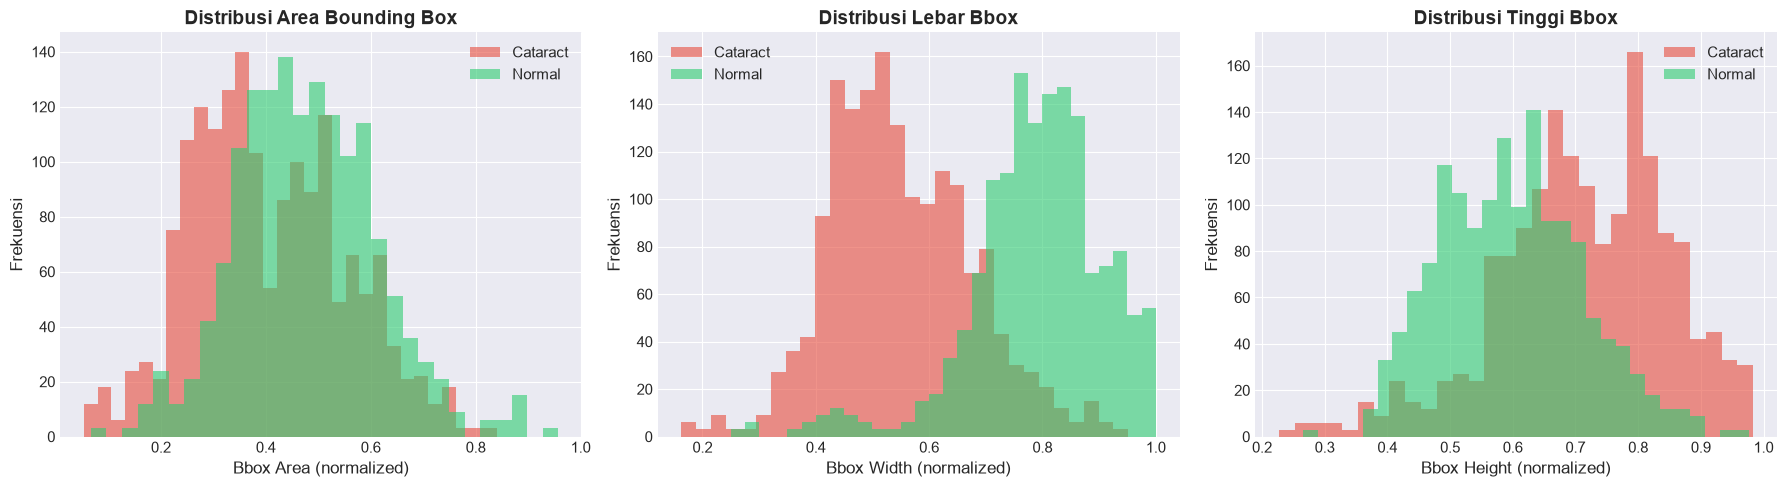

📐 Statistik Bounding Box:
   Area  — mean: 0.4380, std: 0.1465
   Width — mean: 0.6624, std: 0.1721
   Height— mean: 0.6586, std: 0.1390


In [9]:
# 
# 

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Distribusi ukuran bbox (area)
for cls_id in sorted(CLASS_NAMES.keys()):
    subset = df_meta[df_meta['class_id'] == cls_id]
    axes[0].hist(subset['bbox_area'], bins=30, alpha=0.6,
                 label=CLASS_NAMES[cls_id], color=CLASS_COLORS[cls_id])
axes[0].set_xlabel('Bbox Area (normalized)')
axes[0].set_ylabel('Frekuensi')
axes[0].set_title('Distribusi Area Bounding Box', fontweight='bold')
axes[0].legend()

# Distribusi lebar bbox
for cls_id in sorted(CLASS_NAMES.keys()):
    subset = df_meta[df_meta['class_id'] == cls_id]
    axes[1].hist(subset['bbox_w'], bins=30, alpha=0.6,
                 label=CLASS_NAMES[cls_id], color=CLASS_COLORS[cls_id])
axes[1].set_xlabel('Bbox Width (normalized)')
axes[1].set_ylabel('Frekuensi')
axes[1].set_title('Distribusi Lebar Bbox', fontweight='bold')
axes[1].legend()

# Distribusi tinggi bbox
for cls_id in sorted(CLASS_NAMES.keys()):
    subset = df_meta[df_meta['class_id'] == cls_id]
    axes[2].hist(subset['bbox_h'], bins=30, alpha=0.6,
                 label=CLASS_NAMES[cls_id], color=CLASS_COLORS[cls_id])
axes[2].set_xlabel('Bbox Height (normalized)')
axes[2].set_ylabel('Frekuensi')
axes[2].set_title('Distribusi Tinggi Bbox', fontweight='bold')
axes[2].legend()

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'bbox_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f" Statistik Bounding Box:")
print(f"   Area  — mean: {df_meta['bbox_area'].mean():.4f}, std: {df_meta['bbox_area'].std():.4f}")
print(f"   Width — mean: {df_meta['bbox_w'].mean():.4f}, std: {df_meta['bbox_w'].std():.4f}")
print(f"   Height— mean: {df_meta['bbox_h'].mean():.4f}, std: {df_meta['bbox_h'].std():.4f}")

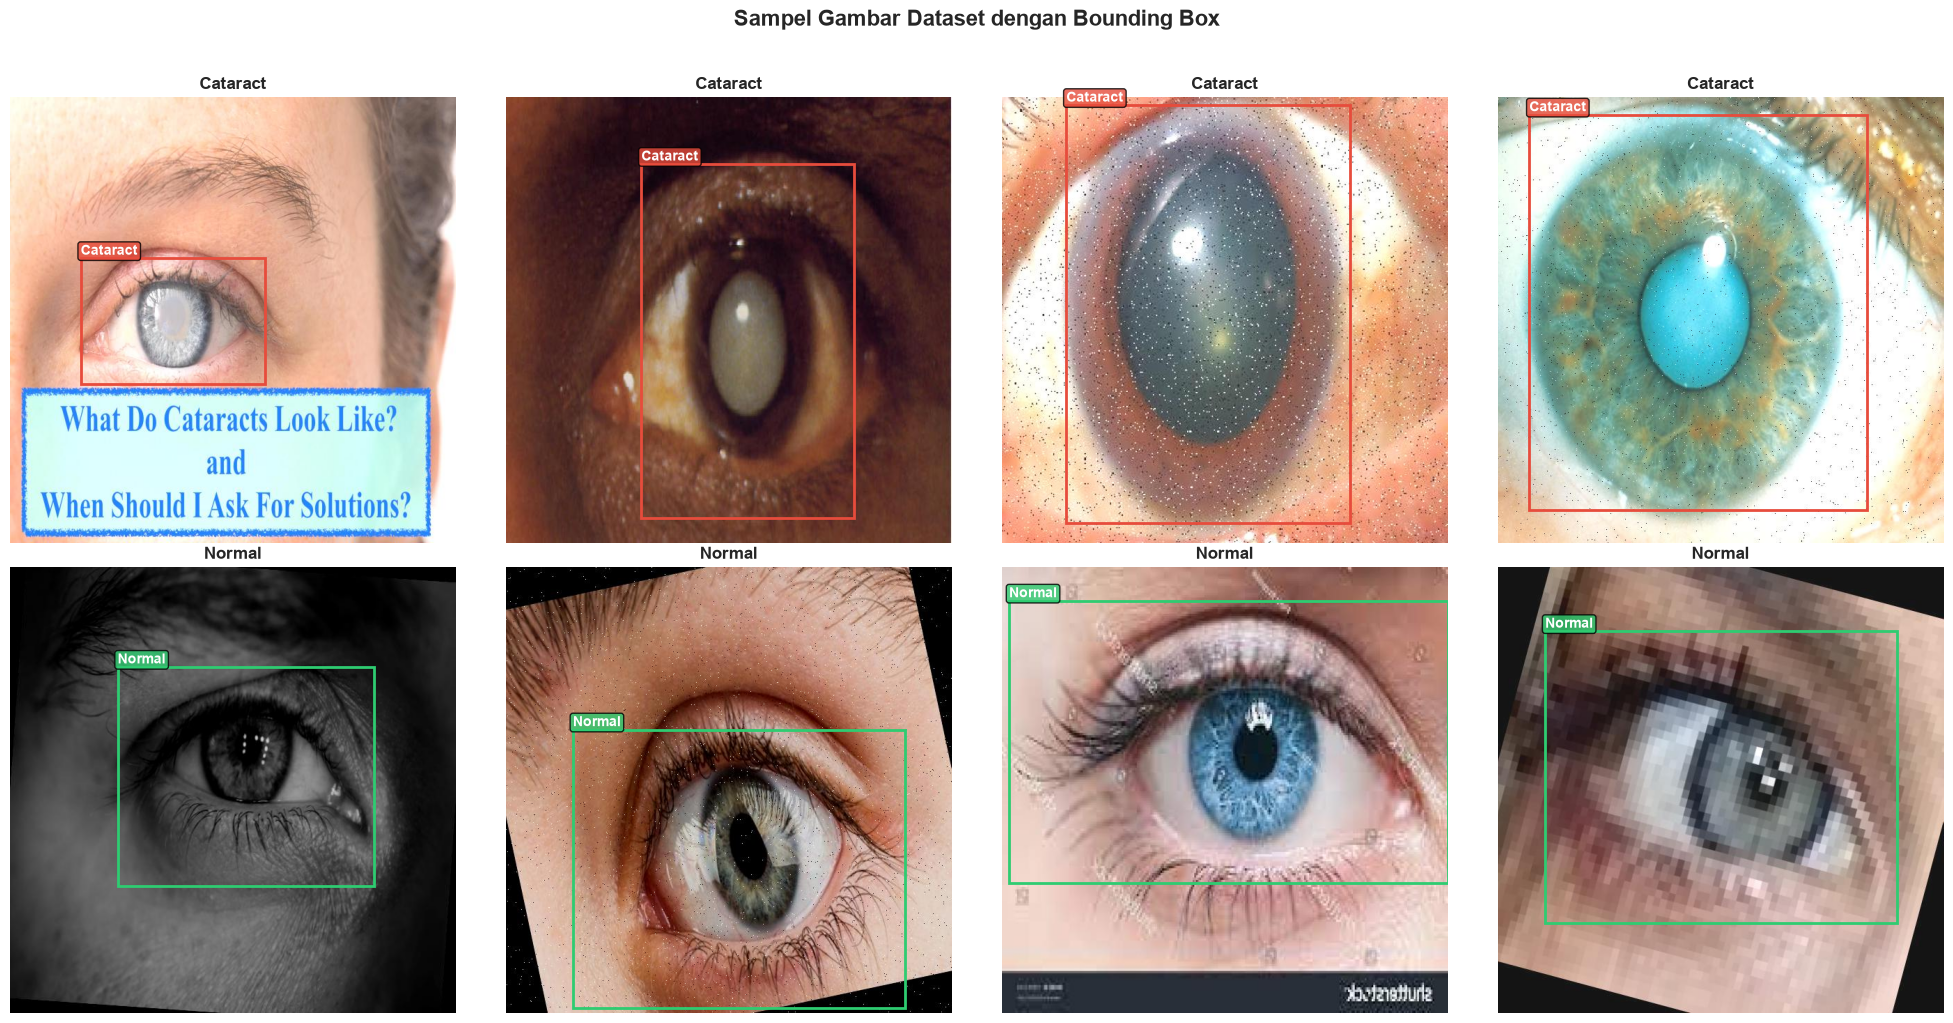

In [10]:
# 
# 

def plot_sample_images(raw_dir: Path, df: pd.DataFrame, n_samples=8):
    """Tampilkan sampel gambar dengan bounding box dari dataset."""
    
    # Ambil sampel seimbang dari setiap kelas
    samples_per_class = n_samples // NUM_CLASSES
    sample_files = []
    
    for cls_id in sorted(CLASS_NAMES.keys()):
        cls_files = df[df['class_id'] == cls_id]['filename'].unique()
        chosen = np.random.choice(cls_files, min(samples_per_class, len(cls_files)), replace=False)
        sample_files.extend(chosen)
    
    cols = 4
    rows = (len(sample_files) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(20, 5 * rows))
    if rows == 1:
        axes = [axes]
    axes = np.array(axes).flatten()
    
    for idx, fname in enumerate(sample_files):
        ax = axes[idx]
        
        # Cari file gambar
        img_path = None
        for split in ['train', 'valid', 'test']:
            candidate = raw_dir / split / 'images' / fname
            if candidate.exists():
                img_path = candidate
                break
        
        if img_path is None:
            continue
        
        img = Image.open(img_path)
        w, h = img.size
        ax.imshow(img)
        
        # Draw bounding boxes
        file_annots = df[df['filename'] == fname]
        for _, row in file_annots.iterrows():
            cls_id = int(row['class_id'])
            bx, by, bw, bh = row['bbox_x'], row['bbox_y'], row['bbox_w'], row['bbox_h']
            
            # Konversi dari YOLO format (center x,y, w,h) ke pixel (x1, y1, w, h)
            x1 = (bx - bw / 2) * w
            y1 = (by - bh / 2) * h
            pw = bw * w
            ph = bh * h
            
            color = CLASS_COLORS.get(cls_id, '#ffffff')
            rect = patches.Rectangle((x1, y1), pw, ph,
                                     linewidth=2, edgecolor=color, facecolor='none')
            ax.add_patch(rect)
            ax.text(x1, y1 - 5, CLASS_NAMES.get(cls_id, '?'),
                    color='white', fontsize=10, fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.2', facecolor=color, alpha=0.8))
        
        ax.set_title(f"{CLASS_NAMES.get(int(file_annots.iloc[0]['class_id']), '?')}",
                     fontsize=12, fontweight='bold')
        ax.axis('off')
    
    # Hide kosong
    for idx in range(len(sample_files), len(axes)):
        axes[idx].axis('off')
    
    plt.suptitle('Sampel Gambar Dataset dengan Bounding Box', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(PROJECT_ROOT / 'sample_images_bbox.png', dpi=150, bbox_inches='tight')
    plt.show()


plot_sample_images(RAW_DATASET_DIR, df_meta, n_samples=8)

---
## Tahap 4: Data Cleaning & Validasi

Proses pembersihan data meliputi:
1. **Validasi gambar** — Cek apakah file gambar bisa dibuka (tidak korup)
2. **Validasi label** — Cek format YOLO (`class_id x y w h`), range [0,1], class_id valid
3. **Cek orphan** — Gambar tanpa label atau label tanpa gambar
4. **Karantina** — Pindahkan file bermasalah ke folder `_quarantine`

In [11]:
# 
# 

def validate_image(image_path: Path) -> dict:
    """Validasi apakah file gambar tidak korup."""
    try:
        with Image.open(image_path) as img:
            img.verify()
        with Image.open(image_path) as img:
            img.load()  # Load penuh untuk deteksi truncated
        return {'valid': True, 'reason': 'OK'}
    except Exception as e:
        return {'valid': False, 'reason': f'Gambar korup: {e}'}


def validate_yolo_label(label_path: Path, num_classes: int) -> dict:
    """
    Validasi file label YOLO.
    Cek: tidak kosong, format benar, class_id valid, koordinat [0,1].
    """
    try:
        text = label_path.read_text(encoding='utf-8').strip()
        
        if not text:
            return {'valid': False, 'reason': 'Label file kosong', 'class_ids': []}
        
        class_ids = []
        for line_num, line in enumerate(text.splitlines(), 1):
            parts = line.strip().split()
            
            if len(parts) < 5:
                return {
                    'valid': False,
                    'reason': f'Baris {line_num}: format tidak lengkap ({len(parts)} kolom)',
                    'class_ids': class_ids
                }
            
            try:
                cls_id = int(parts[0])
            except ValueError:
                return {
                    'valid': False,
                    'reason': f'Baris {line_num}: class_id bukan integer',
                    'class_ids': class_ids
                }
            
            if cls_id < 0 or cls_id >= num_classes:
                return {
                    'valid': False,
                    'reason': f'Baris {line_num}: class_id={cls_id} di luar [0, {num_classes-1}]',
                    'class_ids': class_ids
                }
            
            try:
                coords = [float(x) for x in parts[1:5]]
            except ValueError:
                return {
                    'valid': False,
                    'reason': f'Baris {line_num}: koordinat bukan angka',
                    'class_ids': class_ids
                }
            
            for i, val in enumerate(coords):
                if val < 0.0 or val > 1.0:
                    return {
                        'valid': False,
                        'reason': f'Baris {line_num}: koordinat[{i}]={val} di luar [0,1]',
                        'class_ids': class_ids
                    }
            
            class_ids.append(cls_id)
        
        return {'valid': True, 'reason': 'OK', 'class_ids': class_ids}
    
    except Exception as e:
        return {'valid': False, 'reason': f'Error: {e}', 'class_ids': []}


print(" Fungsi validasi siap.")

✅ Fungsi validasi siap.


In [13]:
# 
# 

def collect_and_clean(raw_dir: Path, quarantine_dir: Path, num_classes: int) -> list:
    """
    Kumpulkan semua data dari semua split, validasi, dan bersihkan.
    File bermasalah dipindahkan ke quarantine.
    
    Returns:
        list of dict: [{'image': Path, 'label': Path, 'class_id': int}, ...]
    """
    if quarantine_dir.exists():
        shutil.rmtree(quarantine_dir)
    quarantine_dir.mkdir(parents=True, exist_ok=True)
    
    valid_pairs = []
    stats = Counter()
    all_files = []
    
    # Kumpulkan semua file dari semua split
    for split_name in ['train', 'valid', 'test']:
        img_dir = raw_dir / split_name / 'images'
        lbl_dir = raw_dir / split_name / 'labels'
        if not img_dir.exists():
            continue
        for img_file in sorted(img_dir.iterdir()):
            if img_file.suffix.lower() in IMAGE_EXTENSIONS:
                lbl_file = lbl_dir / (img_file.stem + '.txt')
                all_files.append((img_file, lbl_file if lbl_file.exists() else None, split_name))
    
    stats['total'] = len(all_files)
    print(f" Memulai validasi {len(all_files)} data...")
    print("" * 60)
    
    for img_path, lbl_path, source in tqdm(all_files, desc='Validasi data'):
        
        # Cek 1: Ada label?
        if lbl_path is None:
            stats['no_label'] += 1
            dest = quarantine_dir / 'no_label'
            dest.mkdir(parents=True, exist_ok=True)
            shutil.copy2(img_path, dest / img_path.name)
            continue
        
        # Cek 2: Gambar valid?
        img_result = validate_image(img_path)
        if not img_result['valid']:
            stats['corrupt_image'] += 1
            dest = quarantine_dir / 'corrupt_image'
            dest.mkdir(parents=True, exist_ok=True)
            shutil.copy2(img_path, dest / img_path.name)
            if lbl_path.exists():
                shutil.copy2(lbl_path, dest / lbl_path.name)
            continue
        
        # Cek 3: Label valid?
        lbl_result = validate_yolo_label(lbl_path, num_classes)
        if not lbl_result['valid']:
            stats['invalid_label'] += 1
            dest = quarantine_dir / 'invalid_label'
            dest.mkdir(parents=True, exist_ok=True)
            shutil.copy2(img_path, dest / img_path.name)
            shutil.copy2(lbl_path, dest / lbl_path.name)
            continue
        
        #  Data valid
        primary_class = lbl_result['class_ids'][0]
        valid_pairs.append({
            'image': img_path,
            'label': lbl_path,
            'class_id': primary_class
        })
        stats['valid'] += 1
    
    print("" * 60)
    print(f"\n Hasil Data Cleaning:")
    print(f"   Total data         : {stats['total']}")
    print(f"    Valid            : {stats['valid']}")
    print(f"    Tanpa label      : {stats.get('no_label', 0)}")
    print(f"    Gambar korup     : {stats.get('corrupt_image', 0)}")
    print(f"    Label invalid    : {stats.get('invalid_label', 0)}")
    print(f"    Quarantine dir  : {quarantine_dir}")
    
    return valid_pairs


# Jalankan
clean_pairs = collect_and_clean(RAW_DATASET_DIR, QUARANTINE_DIR, NUM_CLASSES)
print(f"\n {len(clean_pairs)} data bersih siap untuk split.")

🔍 Memulai validasi 3144 data...
────────────────────────────────────────────────────────────


Validasi data:   0%|          | 0/3144 [00:00<?, ?it/s]

────────────────────────────────────────────────────────────

📊 Hasil Data Cleaning:
   Total data         : 3144
   ✅ Valid            : 3144
   ❌ Tanpa label      : 0
   ❌ Gambar korup     : 0
   ❌ Label invalid    : 0
   📁 Quarantine dir  : d:\UDINUS\SEMESTER 4\PEMBELAJARAN MESIN\SiCASA\_quarantine

✅ 3144 data bersih siap untuk split.


In [14]:
# Distribusi kelas setelah cleaning
clean_class_counts = Counter(p['class_id'] for p in clean_pairs)
print(" Distribusi Kelas Setelah Cleaning:")
print("" * 40)
for cls_id in sorted(clean_class_counts.keys()):
    count = clean_class_counts[cls_id]
    pct = count / len(clean_pairs) * 100
    bar = '' * int(pct / 2)
    print(f"   {CLASS_NAMES[cls_id]:<10} : {count:>5} ({pct:>5.1f}%) {bar}")
print(f"   {'Total':<10} : {len(clean_pairs):>5}")

📊 Distribusi Kelas Setelah Cleaning:
────────────────────────────────────────
   Cataract   :  1674 ( 53.2%) ██████████████████████████
   Normal     :  1470 ( 46.8%) ███████████████████████
   Total      :  3144


---
## Tahap 5: Stratified Split (Train 70% / Val 20% / Test 10%)

Menggunakan `sklearn.model_selection.train_test_split` dengan parameter `stratify`  
untuk **menjamin** distribusi kelas proporsional di setiap partisi.

**Mengapa stratified split penting?**
- Menghindari bias split (misalnya validation set yang hanya berisi 1 kelas)
- Menjamin evaluasi yang representatif
- Standar wajib dalam riset machine learning

In [15]:
# 
# 

def stratified_split(pairs, train_ratio=0.7, val_ratio=0.2, test_ratio=0.1, seed=42):
    """
    Split data secara stratified: distribusi kelas tetap proporsional.
    
    Strategi: Split 2 tahap
      1. Pisahkan test set (10%)
      2. Dari sisa (90%), pisahkan val set (20/90 ≈ 22.2%)
    """
    assert abs(train_ratio + val_ratio + test_ratio - 1.0) < 1e-9, \
        f"Total rasio harus = 1.0, dapat {train_ratio + val_ratio + test_ratio}"
    
    labels = [p['class_id'] for p in pairs]
    
    # Split 1: Pisahkan test
    train_val, test_set, tv_labels, _ = train_test_split(
        pairs, labels,
        test_size=test_ratio,
        random_state=seed,
        stratify=labels
    )
    
    # Split 2: Pisahkan val dari sisa
    relative_val = val_ratio / (train_ratio + val_ratio)
    train_set, val_set = train_test_split(
        train_val,
        test_size=relative_val,
        random_state=seed,
        stratify=tv_labels
    )
    
    return train_set, val_set, test_set


# Jalankan split
train_data, val_data, test_data = stratified_split(
    clean_pairs,
    train_ratio=0.7,
    val_ratio=0.2,
    test_ratio=0.1,
    seed=RANDOM_SEED
)

# Tabel hasil split
print("\n Hasil Stratified Split:")
print("" * 55)
print(f"{'Split':<10} {'Total':>8} {'Cataract':>10} {'Normal':>10} {'Ratio':>10}")
print("" * 55)
for name, data in [('Train', train_data), ('Val', val_data), ('Test', test_data)]:
    cc = Counter(p['class_id'] for p in data)
    ratio = cc.get(0, 0) / max(cc.get(1, 0), 1)
    print(f"{name:<10} {len(data):>8} {cc.get(0, 0):>10} {cc.get(1, 0):>10} {ratio:>9.2f}x")
print("" * 55)
total_cc = Counter(p['class_id'] for p in clean_pairs)
total_ratio = total_cc.get(0, 0) / max(total_cc.get(1, 0), 1)
print(f"{'TOTAL':<10} {len(clean_pairs):>8} {total_cc.get(0, 0):>10} {total_cc.get(1, 0):>10} {total_ratio:>9.2f}x")
print("" * 55)
print("\n Distribusi kelas konsisten di semua split!")


📊 Hasil Stratified Split:
═══════════════════════════════════════════════════════
Split         Total   Cataract     Normal      Ratio
───────────────────────────────────────────────────────
Train          2200       1171       1029      1.14x
Val             629        335        294      1.14x
Test            315        168        147      1.14x
───────────────────────────────────────────────────────
TOTAL          3144       1674       1470      1.14x
═══════════════════════════════════════════════════════

✅ Distribusi kelas konsisten di semua split!


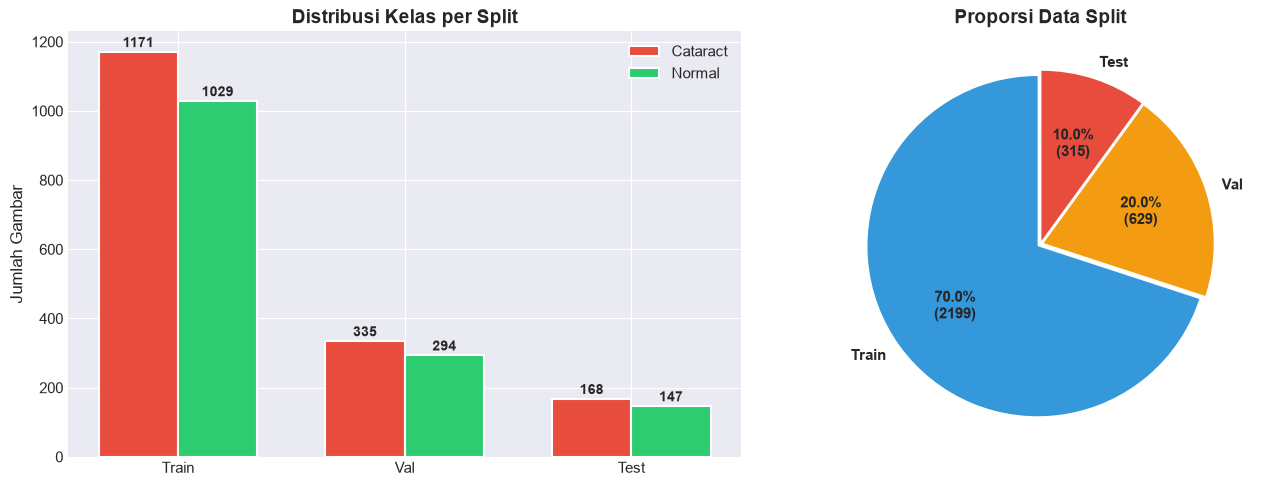

In [16]:
# 
# 

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart per split
split_names = ['Train', 'Val', 'Test']
split_data_list = [train_data, val_data, test_data]

cat_counts = [Counter(p['class_id'] for p in d).get(0, 0) for d in split_data_list]
nor_counts = [Counter(p['class_id'] for p in d).get(1, 0) for d in split_data_list]

x = np.arange(len(split_names))
width = 0.35

bars1 = axes[0].bar(x - width/2, cat_counts, width, label='Cataract',
                     color=CLASS_COLORS[0], edgecolor='white', linewidth=1.5)
bars2 = axes[0].bar(x + width/2, nor_counts, width, label='Normal',
                     color=CLASS_COLORS[1], edgecolor='white', linewidth=1.5)

for bars in [bars1, bars2]:
    for bar in bars:
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                     f'{int(bar.get_height())}', ha='center', va='bottom', fontsize=10, fontweight='bold')

axes[0].set_xticks(x)
axes[0].set_xticklabels(split_names)
axes[0].set_ylabel('Jumlah Gambar')
axes[0].set_title('Distribusi Kelas per Split', fontweight='bold')
axes[0].legend()

# Pie chart proporsi split
split_totals = [len(d) for d in split_data_list]
colors_pie = ['#3498db', '#f39c12', '#e74c3c']
explode = (0.02, 0.02, 0.02)

wedges, texts, autotexts = axes[1].pie(
    split_totals, explode=explode, labels=split_names,
    autopct=lambda pct: f'{pct:.1f}%\n({int(pct/100*sum(split_totals))})',
    colors=colors_pie, startangle=90,
    textprops={'fontsize': 11, 'fontweight': 'bold'}
)
axes[1].set_title('Proporsi Data Split', fontweight='bold')

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'dataset_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Tahap 6: Restrukturisasi Folder YOLOv8

Memindahkan data ke struktur standar YOLOv8:
```
dataset/
 images/
    train/    (70%)
    val/      (20%)
    test/     (10%)
 labels/
    train/
    val/
    test/
 data.yaml
```

In [17]:
# 
# 

def restructure_dataset(train_pairs, val_pairs, test_pairs, output_dir: Path):
    """
    Salin file ke struktur folder YOLOv8 standar.
    Folder lama dihapus dulu untuk menghindari data residual.
    """
    # Hapus folder lama jika ada
    if output_dir.exists():
        print(f"  Menghapus folder lama: {output_dir}")
        shutil.rmtree(output_dir)
    
    splits = {'train': train_pairs, 'val': val_pairs, 'test': test_pairs}
    
    # Buat struktur folder
    for split_name in splits:
        (output_dir / 'images' / split_name).mkdir(parents=True, exist_ok=True)
        (output_dir / 'labels' / split_name).mkdir(parents=True, exist_ok=True)
    
    print(" Menyalin file ke folder baru...")
    print("" * 50)
    
    for split_name, pairs in splits.items():
        img_dest = output_dir / 'images' / split_name
        lbl_dest = output_dir / 'labels' / split_name
        
        for pair in tqdm(pairs, desc=f'  {split_name}', leave=True):
            shutil.copy2(pair['image'], img_dest / pair['image'].name)
            shutil.copy2(pair['label'], lbl_dest / pair['label'].name)
        
        print(f"    {split_name:<6}: {len(pairs)} pasangan")
    
    print("" * 50)
    return output_dir


# Jalankan
restructure_dataset(train_data, val_data, test_data, CLEAN_DATASET_DIR)
print(f"\n Dataset bersih tersimpan di: {CLEAN_DATASET_DIR}")

⚠️  Menghapus folder lama: d:\UDINUS\SEMESTER 4\PEMBELAJARAN MESIN\SiCASA\dataset
📂 Menyalin file ke folder baru...
──────────────────────────────────────────────────


  train:   0%|          | 0/2200 [00:00<?, ?it/s]

   ✅ train : 2200 pasangan


  val:   0%|          | 0/629 [00:00<?, ?it/s]

   ✅ val   : 629 pasangan


  test:   0%|          | 0/315 [00:00<?, ?it/s]

   ✅ test  : 315 pasangan
──────────────────────────────────────────────────

✅ Dataset bersih tersimpan di: d:\UDINUS\SEMESTER 4\PEMBELAJARAN MESIN\SiCASA\dataset


In [18]:
# 
# 

print(" Verifikasi Struktur Folder:")
print("" * 60)
print(f"{'Split':<8} {'Images':>8} {'Labels':>8} {'Match':>8} {'Status':>10}")
print("" * 60)

all_ok = True
for split in ['train', 'val', 'test']:
    n_img = len(list((CLEAN_DATASET_DIR / 'images' / split).glob('*')))
    n_lbl = len(list((CLEAN_DATASET_DIR / 'labels' / split).glob('*.txt')))
    match = n_img == n_lbl
    status = ' OK' if match else ' ERROR'
    if not match:
        all_ok = False
    print(f"{split:<8} {n_img:>8} {n_lbl:>8} {str(match):>8} {status:>10}")

print("" * 60)
if all_ok:
    print(" Semua split terverifikasi — images dan labels cocok!")
else:
    print(" PERINGATAN: Ada ketidakcocokan! Periksa kembali data.")

📋 Verifikasi Struktur Folder:
════════════════════════════════════════════════════════════
Split      Images   Labels    Match     Status
────────────────────────────────────────────────────────────
train        2200     2200     True       ✅ OK
val           629      629     True       ✅ OK
test          315      315     True       ✅ OK
════════════════════════════════════════════════════════════
✅ Semua split terverifikasi — images dan labels cocok!


---
## Tahap 7: Generate `data.yaml`

File konfigurasi yang dibutuhkan YOLOv8 untuk mengetahui lokasi dataset dan daftar kelas.

In [19]:
# 
# GENERATE DATA.YAML
# 

def generate_data_yaml(dataset_dir: Path, class_names: dict) -> Path:
    """Buat file data.yaml dengan path absolut."""
    
    output_path = dataset_dir / 'data.yaml'
    dataset_abs = str(dataset_dir.resolve()).replace('\\', '/')
    
    data_config = {
        'path': dataset_abs,
        'train': 'images/train',
        'val': 'images/val',
        'test': 'images/test',
        'nc': len(class_names),
        'names': [class_names[i] for i in sorted(class_names.keys())]
    }
    
    with open(output_path, 'w', encoding='utf-8') as f:
        yaml.dump(data_config, f, default_flow_style=False, sort_keys=False, allow_unicode=True)
    
    print(f" data.yaml berhasil dibuat: {output_path}")
    print(f"\n Isi data.yaml:")
    print("" * 50)
    print(output_path.read_text(encoding='utf-8'))
    print("" * 50)
    
    # Verifikasi semua path ada
    print("\n Verifikasi path:")
    for key in ['train', 'val', 'test']:
        full_path = dataset_dir / data_config[key]
        exists = full_path.exists()
        status = '' if exists else ''
        print(f"   {status} {key}: {full_path}")
    
    return output_path


DATA_YAML_PATH = generate_data_yaml(CLEAN_DATASET_DIR, CLASS_NAMES)

✅ data.yaml berhasil dibuat: d:\UDINUS\SEMESTER 4\PEMBELAJARAN MESIN\SiCASA\dataset\data.yaml

📄 Isi data.yaml:
──────────────────────────────────────────────────
path: D:/UDINUS/SEMESTER 4/PEMBELAJARAN MESIN/SiCASA/dataset
train: images/train
val: images/val
test: images/test
nc: 2
names:
- Cataract
- Normal

──────────────────────────────────────────────────

🔍 Verifikasi path:
   ✅ train: d:\UDINUS\SEMESTER 4\PEMBELAJARAN MESIN\SiCASA\dataset\images\train
   ✅ val: d:\UDINUS\SEMESTER 4\PEMBELAJARAN MESIN\SiCASA\dataset\images\val
   ✅ test: d:\UDINUS\SEMESTER 4\PEMBELAJARAN MESIN\SiCASA\dataset\images\test


---
## Tahap 8: Training Model YOLOv8

### Konfigurasi Training (Akademis & Optimal):

| Parameter | Nilai | Alasan |
|:----------|:------|:-------|
| `seed` | 42 | Reproduktibilitas hasil |
| `epochs` | 300 | Cukup untuk konvergensi |
| `patience` | 20 | Early stopping → cegah overfitting |
| `save_period` | 5 | Checkpoint tiap 5 epoch |
| `imgsz` | 640 | Resolusi standar YOLOv8 |
| `batch` | -1 | Auto-batch sesuai GPU VRAM |
| `optimizer` | auto | YOLOv8 pilih optimizer terbaik |
| `lr0` | 0.01 | Learning rate awal standar |
| `lrf` | 0.01 | Learning rate akhir (cosine decay) |
| `mosaic` | 1.0 | Augmentasi mosaic (aktif) |
| `mixup` | 0.1 | Augmentasi MixUp → regularisasi tambahan |
| `copy_paste` | 0.1 | Copy-Paste augmentation → variasi objek |

> **Saran Expert:**  
> - `mixup=0.1` dan `copy_paste=0.1` adalah teknik augmentasi lanjutan yang membantu model  
>   belajar fitur yang lebih robust, terutama pada dataset medis yang ukurannya terbatas.  
> - `cos_lr=True` menggunakan cosine annealing yang lebih smooth dibanding step decay.

In [20]:
# 
# CEK GPU & HARDWARE
# 

print("  Hardware Check:")
print("" * 50)
print(f"   CUDA available  : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"   GPU             : {torch.cuda.get_device_name(0)}")
    props = torch.cuda.get_device_properties(0)
    vram_gb = props.total_memory / (1024**3)
    print(f"   VRAM            : {vram_gb:.1f} GB")
    print(f"   CUDA version    : {torch.version.cuda}")
    print(f"   cuDNN version   : {torch.backends.cudnn.version()}")
    device_str = '0'
else:
    print("     GPU tidak tersedia — training di CPU (sangat lambat!)")
    device_str = 'cpu'
print("" * 50)
print(f"   Device training : {device_str}")

🖥️  Hardware Check:
══════════════════════════════════════════════════
   CUDA available  : True
   GPU             : NVIDIA GeForce RTX 3050 6GB Laptop GPU
   VRAM            : 6.0 GB
   CUDA version    : 11.8
   cuDNN version   : 90100
══════════════════════════════════════════════════
   Device training : 0


In [21]:
# 
# 

# Pilih model base (uncomment sesuai kebutuhan)
BASE_MODEL = 'yolov8s.pt'     # Small  — balance speed & accuracy
# BASE_MODEL = 'yolov8s.pt'   # Small  — balance speed & accuracy
# BASE_MODEL = 'yolov8m.pt'   # Medium — lebih akurat, butuh VRAM lebih
# BASE_MODEL = 'yolov8l.pt'   # Large  — sangat akurat, butuh GPU besar

# Path konfigurasi
DATA_YAML    = str(DATA_YAML_PATH)
PROJECT_NAME = str(RUNS_DIR / 'detect')
RUN_NAME     = 'SiCASA_CataractScan'

print(f" Base model    : {BASE_MODEL}")
print(f" Data config   : {DATA_YAML}")
print(f" Output        : {PROJECT_NAME}/{RUN_NAME}")
print(f" Device        : {device_str}")

📦 Base model    : yolov8s.pt
📄 Data config   : d:\UDINUS\SEMESTER 4\PEMBELAJARAN MESIN\SiCASA\dataset\data.yaml
📁 Output        : d:\UDINUS\SEMESTER 4\PEMBELAJARAN MESIN\SiCASA\runs\detect/SiCASA_CataractScan
🎯 Device        : 0


In [ ]:
# 
#  MULAI TRAINING (dengan proteksi auto-resume)
# 

from pathlib import Path
FINISH_FLAG = Path(PROJECT_NAME) / RUN_NAME / 'training_finished.flag'
BEST_PT = Path(PROJECT_NAME) / RUN_NAME / 'weights' / 'best.pt'
LAST_PT = Path(PROJECT_NAME) / RUN_NAME / 'weights' / 'last.pt'

if FINISH_FLAG.exists() and BEST_PT.exists():
    print("Training sudah selesai 100% sebelumnya.")
    print(f"Model terbaik: {BEST_PT}")
    print("Melewati proses training.")
elif BEST_PT.exists():
    print("Training terdeteksi sudah selesai (best.pt ditemukan).")
    print("Membuat ulang training_finished.flag...")
    FINISH_FLAG.touch()
elif LAST_PT.exists():
    print("Training terputus sebelumnya. Melanjutkan (resume)...")
    model = YOLO(str(LAST_PT))
    results = model.train(resume=True)
    FINISH_FLAG.touch()
    print("\n" + "=" * 60)
    print("TRAINING SELESAI!")
    print("=" * 60)
else:
    model = YOLO(BASE_MODEL)

    results = model.train(
        data=DATA_YAML,
        epochs=300,
        imgsz=640,
        batch=-1,
        device=device_str,
        seed=42,
        patience=20,
        save_period=5,
        deterministic=True,
        optimizer='auto',
        lr0=0.01,
        lrf=0.01,
        cos_lr=True,
        warmup_epochs=3.0,
        warmup_momentum=0.8,
        mosaic=1.0,
        mixup=0.1,
        copy_paste=0.1,
        hsv_h=0.015,
        hsv_s=0.7,
        hsv_v=0.4,
        flipud=0.5,
        fliplr=0.5,
        degrees=10.0,
        translate=0.1,
        scale=0.5,
        project=PROJECT_NAME,
        name=RUN_NAME,
        exist_ok=True,
        pretrained=True,
        verbose=True,
        val=True,
        plots=True,
        save=True,
        save_json=False,
    )

    FINISH_FLAG.touch()
    print("\n" + "=" * 60)
    print("TRAINING SELESAI!")
    print("=" * 60)

New https://pypi.org/project/ultralytics/8.4.70 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.67  Python-3.11.15 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce RTX 3050 6GB Laptop GPU, 6144MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=-1, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.1, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=d:\UDINUS\SEMESTER 4\PEMBELAJARAN MESIN\SiCASA\dataset\data.yaml, degrees=10.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=300, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolov

---
## Tahap 9: Evaluasi & Analisis Performa

Evaluasi model terbaik (`best.pt`) pada:
1. **Validation Set** — untuk mengukur performa saat training
2. **Test Set** — untuk mengukur generalisasi model (data yang belum pernah dilihat)

In [ ]:
# 
# 

from pathlib import Path
BEST_MODEL_PATH = Path(PROJECT_NAME) / RUN_NAME / 'weights' / 'best.pt'
LAST_MODEL_PATH = Path(PROJECT_NAME) / RUN_NAME / 'weights' / 'last.pt'

print(f" Best model : {BEST_MODEL_PATH} {'' if BEST_MODEL_PATH.exists() else ''}")
print(f" Last model : {LAST_MODEL_PATH} {'' if LAST_MODEL_PATH.exists() else ''}")

best_model = YOLO(str(BEST_MODEL_PATH))

In [ ]:
# 
# 

print(" Evaluasi pada VALIDATION set...")
print("" * 60)

val_results = best_model.val(
    data=DATA_YAML,
    split='val',
    verbose=True,
    plots=True,
    device=device_str,
)

print(f"\n Metrik Validasi:")
print("" * 40)
print(f"   Precision        : {val_results.box.mp:.4f}")
print(f"   Recall           : {val_results.box.mr:.4f}")
print(f"   mAP@0.5          : {val_results.box.map50:.4f}")
print(f"   mAP@0.5:0.95     : {val_results.box.map:.4f}")
print("" * 40)

In [ ]:
# 
# 

print(" Evaluasi pada TEST set (unseen data)...")
print("" * 60)

test_results = best_model.val(
    data=DATA_YAML,
    split='test',
    verbose=True,
    plots=True,
    device=device_str,
)

print(f"\n Metrik Test Set:")
print("" * 40)
print(f"   Precision        : {test_results.box.mp:.4f}")
print(f"   Recall           : {test_results.box.mr:.4f}")
print(f"   mAP@0.5          : {test_results.box.map50:.4f}")
print(f"   mAP@0.5:0.95     : {test_results.box.map:.4f}")
print("" * 40)

In [ ]:
# 
# 

print("\n Perbandingan Performa Val vs Test:")
print("" * 55)
print(f"{'Metrik':<20} {'Validation':>15} {'Test':>15}")
print("" * 55)
print(f"{'Precision':<20} {val_results.box.mp:>15.4f} {test_results.box.mp:>15.4f}")
print(f"{'Recall':<20} {val_results.box.mr:>15.4f} {test_results.box.mr:>15.4f}")
print(f"{'mAP@0.5':<20} {val_results.box.map50:>15.4f} {test_results.box.map50:>15.4f}")
print(f"{'mAP@0.5:0.95':<20} {val_results.box.map:>15.4f} {test_results.box.map:>15.4f}")
print("" * 55)

# Cek overfitting (perbedaan besar antara val & test = overfitting)
gap = abs(val_results.box.map50 - test_results.box.map50)
if gap < 0.05:
    print(f"\n Gap Val-Test = {gap:.4f} → Model TIDAK overfitting (generalisasi baik!)")
elif gap < 0.10:
    print(f"\n  Gap Val-Test = {gap:.4f} → Sedikit overfitting, masih acceptable")
else:
    print(f"\n Gap Val-Test = {gap:.4f} → Model OVERFITTING! Pertimbangkan regularisasi lebih.")

---
## Tahap 10: Visualisasi Hasil Prediksi

Tampilkan hasil inferensi pada sampel gambar test set untuk verifikasi visual.

In [ ]:
# 
# 

results_csv = Path(PROJECT_NAME) / RUN_NAME / 'results.csv'

if results_csv.exists():
    df_train = pd.read_csv(results_csv)
    df_train.columns = df_train.columns.str.strip()  # Bersihkan spasi
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    
    # Loss curves
    loss_cols = [
        ('train/box_loss', 'val/box_loss', 'Box Loss'),
        ('train/cls_loss', 'val/cls_loss', 'Classification Loss'),
        ('train/dfl_loss', 'val/dfl_loss', 'DFL Loss'),
    ]
    
    for idx, (train_col, val_col, title) in enumerate(loss_cols):
        ax = axes[0, idx]
        if train_col in df_train.columns:
            ax.plot(df_train['epoch'], df_train[train_col], label='Train', color='#3498db', linewidth=1.5)
        if val_col in df_train.columns:
            ax.plot(df_train['epoch'], df_train[val_col], label='Val', color='#e74c3c', linewidth=1.5)
        ax.set_title(title, fontweight='bold')
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Loss')
        ax.legend()
        ax.grid(True, alpha=0.3)
    
    # Metric curves
    metric_cols = [
        ('metrics/precision(B)', 'Precision'),
        ('metrics/recall(B)', 'Recall'),
        ('metrics/mAP50(B)', 'mAP@0.5'),
    ]
    
    for idx, (col, title) in enumerate(metric_cols):
        ax = axes[1, idx]
        if col in df_train.columns:
            ax.plot(df_train['epoch'], df_train[col], color='#2ecc71', linewidth=2)
            ax.fill_between(df_train['epoch'], df_train[col], alpha=0.1, color='#2ecc71')
            # Tandai nilai terbaik
            best_idx = df_train[col].idxmax()
            ax.scatter(df_train.loc[best_idx, 'epoch'], df_train.loc[best_idx, col],
                       color='red', s=100, zorder=5, marker='*',
                       label=f'Best: {df_train.loc[best_idx, col]:.4f}')
        ax.set_title(title, fontweight='bold')
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Score')
        ax.legend()
        ax.grid(True, alpha=0.3)
    
    plt.suptitle('Training & Validation Curves', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig(PROJECT_ROOT / 'training_curves.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("  results.csv tidak ditemukan. Jalankan training dulu (Tahap 8).")

In [ ]:
# 
# 

test_images_dir = CLEAN_DATASET_DIR / 'images' / 'test'
test_images = sorted(list(test_images_dir.glob('*')))

# Ambil 8 sampel acak
n_samples = min(8, len(test_images))
sample_indices = np.random.choice(len(test_images), n_samples, replace=False)
sample_images = [test_images[i] for i in sample_indices]

# Jalankan inferensi
fig, axes = plt.subplots(2, 4, figsize=(24, 12))
axes = axes.flatten()

for idx, img_path in enumerate(sample_images):
    # Inferensi
    result = best_model(str(img_path), conf=0.25, verbose=False)[0]
    result_img = result.plot()  # BGR
    result_img = result_img[:, :, ::-1]  # BGR → RGB
    
    axes[idx].imshow(result_img)
    
    # Title dengan hasil deteksi
    if len(result.boxes) > 0:
        cls_name = result.names[int(result.boxes.cls[0])]
        conf_val = float(result.boxes.conf[0]) * 100
        axes[idx].set_title(f'{cls_name} ({conf_val:.1f}%)', fontsize=12, fontweight='bold',
                           color='red' if 'Cataract' in cls_name else 'green')
    else:
        axes[idx].set_title('No Detection', fontsize=12, color='gray')
    
    axes[idx].axis('off')

# Hide extra axes
for idx in range(len(sample_images), len(axes)):
    axes[idx].axis('off')

plt.suptitle('Hasil Prediksi pada Test Set', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'inference_results.png', dpi=150, bbox_inches='tight')
plt.show()

print(f" {n_samples} sampel prediksi ditampilkan.")

---
## Tahap 11: Deploy ke Web App SiCASA

Salin `best.pt` ke folder `app/` agar web app bisa langsung menggunakannya.

In [ ]:
# 
# DEPLOY: SALIN best.pt KE FOLDER APP
# 

APP_MODEL_PATH = APP_DIR / 'best.pt'

if BEST_MODEL_PATH.exists():
    shutil.copy2(BEST_MODEL_PATH, APP_MODEL_PATH)
    size_mb = APP_MODEL_PATH.stat().st_size / (1024 * 1024)
    
    print("" * 60)
    print(" MODEL BERHASIL DI-DEPLOY!")
    print("" * 60)
    print(f"   Source  : {BEST_MODEL_PATH}")
    print(f"   Dest    : {APP_MODEL_PATH}")
    print(f"   Size    : {size_mb:.1f} MB")
    print(f"")
    print(f"    Untuk menjalankan web app:")
    print(f"   > python app/app.py")
    print(f"   > atau klik run_website.bat")
    print(f"   > lalu buka http://localhost:5000")
    print("" * 60)
else:
    print(" File best.pt tidak ditemukan.")
    print(f"   Path dicari: {BEST_MODEL_PATH}")
    print(f"   Pastikan training (Tahap 8) sudah selesai dengan sukses.")

In [ ]:
# 
# 

print("\n")
print("" + "" * 58 + "")
print("" + "  SiCASA — CataractScan Pipeline COMPLETE ".center(58) + "")
print("" + "" * 58 + "")
print("" + "".center(58) + "")
print("" + f"   Dataset Bersih   : {len(clean_pairs)} gambar".ljust(58) + "")
print("" + f"   Train            : {len(train_data)} gambar (70%)".ljust(58) + "")
print("" + f"   Validation       : {len(val_data)} gambar (20%)".ljust(58) + "")
print("" + f"   Test             : {len(test_data)} gambar (10%)".ljust(58) + "")
print("" + "".center(58) + "")
print("" + f"   Val mAP@0.5      : {val_results.box.map50:.4f}".ljust(58) + "")
print("" + f"   Test mAP@0.5     : {test_results.box.map50:.4f}".ljust(58) + "")
print("" + "".center(58) + "")
print("" + f"   Best model       : {BEST_MODEL_PATH.name}".ljust(58) + "")
print("" + f"   Web app model    : {APP_MODEL_PATH}".ljust(58) + "")
print("" + f"   Web URL          : http://localhost:5000".ljust(58) + "")
print("" + "".center(58) + "")
print("" + "" * 58 + "")
print("\n Selamat! Pipeline selesai. Jalankan run_website.bat untuk demo!")